# 06 - Latest HDF5 thresholded pulse selection diagnostics

This notebook is only for real HDF5 pulse extraction diagnostics and data-driven peak-cut selection. It does not run CORSIKA simulation or final real-vs-sim matching.

Default input is the latest Panel A HDF5 file:

`data/raw/Test_Panel/03A_040526_1h50m_AMP5_C5_thr0_82.h5`

Panel B is supported through `PRIMARY_PANEL = "B"`, but Panel A is the first-priority diagnostic target.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

LATEST_H5_FILES = {
    "A": PROJECT_ROOT / "data/raw/Test_Panel/03A_040526_1h50m_AMP5_C5_thr0_82.h5",
    "B": PROJECT_ROOT / "data/raw/Test_Panel/03B_040526_1h50m_AMP5_C5_thr0_123.h5",
}

OUTPUT_TABLES = PROJECT_ROOT / "outputs/tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs/figures"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
for panel, path in LATEST_H5_FILES.items():
    print(f"Panel {panel} HDF5 exists:", path.exists(), path)


Project root: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework
Panel A HDF5 exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03A_040526_1h50m_AMP5_C5_thr0_82.h5
Panel B HDF5 exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03B_040526_1h50m_AMP5_C5_thr0_123.h5


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from IPython.display import display

from tambo_sipm.io import (
    estimate_sampling_interval_ns,
    format_test_panel_voltage_unit_report,
    load_test_panel_h5_samples,
    sampling_interval_report,
)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

print("Imports OK")


Imports OK


## 1. Parameters

`THRESHOLD_MV = 18.0` defines pulse start/end after local baseline subtraction. It is not a final high-quality event cut. A separate `MIN_PEAK_MV` will be selected later using diagnostics.

The Red Pitaya FPGA temporal resolution is 8 ns, so width/time histogram bins use 8 ns.


In [3]:
PRIMARY_PANEL = "A"  # "A" or "B"
assert PRIMARY_PANEL in {"A", "B"}

VOLTAGE_UNIT = "auto"
H5_MAX_ROWS = None  # None = full selected HDF5 file. Use an int for fast debugging.

GAP_THRESHOLD_NS = 50.0
MIN_CANDIDATE_SAMPLES = 2

THRESHOLD_MV = 18.0
BASELINE_N_SAMPLES = 8
BASELINE_LOW_PERCENTILE = 30.0
TEMPORAL_BIN_NS = 8.0

MIN_PEAK_CANDIDATES_MV = [30, 40, 50, 60, 80, 100]
RANDOM_SEED = 42
N_WAVEFORM_OVERLAY = 60

PANEL_PREFIX = f"latest_h5_panel_{PRIMARY_PANEL}"
DATA_H5 = LATEST_H5_FILES[PRIMARY_PANEL]

print("Primary panel:", PRIMARY_PANEL)
print("HDF5:", DATA_H5)
print("H5_MAX_ROWS:", H5_MAX_ROWS)
print("Threshold for pulse boundaries [mV]:", THRESHOLD_MV)
print("Temporal bin size [ns]:", TEMPORAL_BIN_NS)


Primary panel: A
HDF5: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03A_040526_1h50m_AMP5_C5_thr0_82.h5
H5_MAX_ROWS: None
Threshold for pulse boundaries [mV]: 18.0
Temporal bin size [ns]: 8.0


## 2. Load HDF5 samples


In [4]:
samples = load_test_panel_h5_samples(
    DATA_H5,
    voltage_unit=VOLTAGE_UNIT,
    max_rows=H5_MAX_ROWS,
)
samples = samples.sort_values("time_ns").reset_index(drop=True)

total_samples = len(samples)
time_span_seconds = float((samples["time_ns"].iloc[-1] - samples["time_ns"].iloc[0]) / 1e9)
estimated_dt_ns = estimate_sampling_interval_ns(samples)

print("Total samples loaded:", total_samples)
print("Time span [s]:", time_span_seconds)
print("Estimated sampling interval [ns]:", estimated_dt_ns)
print("Voltage report:")
print(format_test_panel_voltage_unit_report(samples))
print(sampling_interval_report(samples))
display(samples[["sample_index", "adc_value", "voltage_raw", "voltage_mV", "time_total_seconds", "time_ns"]].head())
display(samples[["adc_value", "voltage_raw", "voltage_mV", "time_ns"]].describe())


Total samples loaded: 14682944
Time span [s]: 6966.085124584
Estimated sampling interval [ns]: 8.0
Voltage report:
Test_Panel voltage unit report
requested voltage_unit: auto
resolved voltage unit: V
conversion assumption: auto uses median(abs(voltaje)): values below 5.0 are interpreted as V and converted to mV; values at or above 5.0 are interpreted as mV.

column,min,median,max
voltage_raw,-0.296826,0.007076,0.999302
voltage_mV,-296.826,7.076,999.302
Test_Panel sampling interval report
estimated_sampling_interval_ns: 8
reference_interval_ns: 8
difference_ns: 0
approximately_reference: True
decision: estimated interval is approximately 8 ns (within +/- 0.25 ns).


,sample_index,adc_value,voltage_raw,voltage_mV,time_total_seconds,time_ns
0,0,-47,-0.005734,-5.734,0.006881,6881208.0
1,1,3,0.000366,0.366,0.006881,6881216.0
2,2,70,0.008540,8.540,0.006881,6881224.0
3,3,86,0.010492,10.492,0.006881,6881232.0
4,4,88,0.010736,10.736,0.006881,6881240.0


,adc_value,voltage_raw,voltage_mV,time_ns
count,1.468294e+07,1.468294e+07,1.468294e+07,1.468294e+07
mean,8.780375e+01,1.071206e-02,1.071206e+01,3.478118e+12
std,1.603170e+02,1.955867e-02,1.955867e+01,2.007248e+12
min,-2.433000e+03,-2.968260e-01,-2.968260e+02,6.881208e+06
25%,1.200000e+01,1.464000e-03,1.464000e+00,1.744367e+12
50%,5.800000e+01,7.076000e-03,7.076000e+00,3.468217e+12
75%,1.150000e+02,1.403000e-02,1.403000e+01,5.215110e+12
max,8.191000e+03,9.993020e-01,9.993020e+02,6.966092e+12


## 3. Initial candidate segmentation by temporal gaps

This step identifies candidate acquisition windows only. It is not the final physical pulse definition.


In [5]:
def build_gap_candidate_windows(samples, gap_threshold_ns=50.0, min_samples=2):
    time_ns = samples["time_ns"].to_numpy(dtype=float)
    if len(time_ns) < min_samples:
        raise ValueError("Not enough samples for candidate segmentation.")
    gaps = np.diff(time_ns)
    starts = np.concatenate(([0], np.where(gaps > gap_threshold_ns)[0] + 1))
    ends = np.concatenate((starts[1:] - 1, [len(samples) - 1]))
    rows = []
    candidate_id = 0
    source_file = samples["source_file"].iloc[0]
    panel = samples["panel"].iloc[0]
    run_id = samples["run_id"].iloc[0]
    for start, end in zip(starts, ends):
        n_samples = int(end - start + 1)
        if n_samples < min_samples:
            continue
        rows.append(
            {
                "candidate_id": candidate_id,
                "event_id": f"threshold_candidate_{panel}_{candidate_id:06d}",
                "row_start": int(start),
                "row_end": int(end),
                "candidate_start_time_ns": float(time_ns[start]),
                "candidate_end_time_ns": float(time_ns[end]),
                "n_samples_candidate": n_samples,
                "source_file": source_file,
                "panel": panel,
                "run_id": run_id,
                "acquisition_date": samples["acquisition_date"].iloc[0],
                "acquisition_duration": samples["acquisition_duration"].iloc[0],
                "threshold_token": samples["threshold_token"].iloc[0],
            }
        )
        candidate_id += 1
    return pd.DataFrame(rows)


candidate_windows = build_gap_candidate_windows(
    samples,
    gap_threshold_ns=GAP_THRESHOLD_NS,
    min_samples=MIN_CANDIDATE_SAMPLES,
)
candidate_rate_hz = len(candidate_windows) / time_span_seconds

print("Candidate windows:", len(candidate_windows))
print("Candidate rate [Hz]:", candidate_rate_hz)
display(candidate_windows[["event_id", "candidate_start_time_ns", "candidate_end_time_ns", "n_samples_candidate"]].head())
display(candidate_windows["n_samples_candidate"].describe())


Candidate windows: 426568
Candidate rate [Hz]: 61.23496804461943


,event_id,candidate_start_time_ns,candidate_end_time_ns,n_samples_candidate
0,threshold_candidate_A_000000,6881208.0,6881400.0,25
1,threshold_candidate_A_000001,29659584.0,29659776.0,25
2,threshold_candidate_A_000002,32668448.0,32668696.0,32
3,threshold_candidate_A_000003,34656616.0,34656920.0,39
4,threshold_candidate_A_000004,47076712.0,47077032.0,41


count    426568.000000
mean         34.421110
std          11.418337
min           3.000000
25%          26.000000
50%          32.000000
75%          40.000000
max         213.000000
Name: n_samples_candidate, dtype: float64

## 4. Baseline-corrected threshold pulse extraction


In [6]:
def robust_baseline(candidate_voltage_mV, peak_index, n_baseline=8, low_percentile=30.0):
    if peak_index >= max(3, n_baseline):
        region = candidate_voltage_mV[: min(n_baseline, peak_index)]
        method = "pre_peak_initial_median"
    else:
        cutoff = np.percentile(candidate_voltage_mV, low_percentile)
        region = candidate_voltage_mV[candidate_voltage_mV <= cutoff]
        if len(region) < 3:
            region = candidate_voltage_mV
        method = f"low_percentile_{low_percentile:g}_median"
    baseline = float(np.median(region))
    mad = float(np.median(np.abs(region - np.median(region))))
    baseline_rms = float(1.4826 * mad)
    return baseline, baseline_rms, method


def threshold_extract_one_candidate(samples, row, threshold_mV=18.0):
    start = int(row["row_start"])
    end = int(row["row_end"])
    candidate = samples.iloc[start : end + 1]
    time_ns_abs = candidate["time_ns"].to_numpy(dtype=float)
    time_ns_rel = time_ns_abs - time_ns_abs[0]
    voltage_mV = candidate["voltage_mV"].to_numpy(dtype=float)
    sample_indices = candidate["sample_index"].to_numpy(dtype=np.int64)

    raw_peak_index = int(np.argmax(voltage_mV))
    baseline_mV, baseline_rms_mV, baseline_method = robust_baseline(
        voltage_mV,
        peak_index=raw_peak_index,
        n_baseline=BASELINE_N_SAMPLES,
        low_percentile=BASELINE_LOW_PERCENTILE,
    )
    corrected = voltage_mV - baseline_mV
    peak_index = int(np.argmax(corrected))
    peak_mV = float(corrected[peak_index])
    n_above = int(np.sum(corrected >= threshold_mV))
    snr_peak = float(peak_mV / baseline_rms_mV) if baseline_rms_mV > 0 else np.inf

    output = row.to_dict()
    output.update(
        {
            "baseline_mV": baseline_mV,
            "baseline_rms_mV": baseline_rms_mV,
            "baseline_method": baseline_method,
            "threshold_mV": float(threshold_mV),
            "peak_mV": peak_mV,
            "snr_peak": snr_peak,
            "n_samples_above_threshold": n_above,
            "valid_threshold_pulse": bool(peak_mV >= threshold_mV),
            "threshold_start_time_ns": np.nan,
            "threshold_end_time_ns": np.nan,
            "threshold_start_sample_index": np.nan,
            "threshold_end_sample_index": np.nan,
            "width_ns": np.nan,
            "integral_mVns": np.nan,
            "rms_mV": np.nan,
            "n_samples_thresholded": 0,
            "peak_index_in_candidate": peak_index,
        }
    )

    if peak_mV < threshold_mV:
        return output

    left = peak_index
    while left > 0 and corrected[left - 1] >= threshold_mV:
        left -= 1
    right = peak_index
    while right < len(corrected) - 1 and corrected[right + 1] >= threshold_mV:
        right += 1

    threshold_time = time_ns_rel[left : right + 1]
    threshold_voltage = corrected[left : right + 1]
    width_ns = float(threshold_time[-1] - threshold_time[0])
    integral_mVns = (
        float(np.trapezoid(threshold_voltage, threshold_time))
        if len(threshold_time) >= 2
        else 0.0
    )
    rms_mV = float(np.sqrt(np.mean(threshold_voltage**2)))

    output.update(
        {
            "threshold_start_time_ns": float(threshold_time[0]),
            "threshold_end_time_ns": float(threshold_time[-1]),
            "threshold_start_sample_index": int(sample_indices[left]),
            "threshold_end_sample_index": int(sample_indices[right]),
            "width_ns": width_ns,
            "integral_mVns": integral_mVns,
            "rms_mV": rms_mV,
            "n_samples_thresholded": int(right - left + 1),
        }
    )
    return output


feature_rows = [
    threshold_extract_one_candidate(samples, row, threshold_mV=THRESHOLD_MV)
    for _, row in candidate_windows.iterrows()
]
features = pd.DataFrame(feature_rows)
features.to_csv(
    OUTPUT_TABLES / f"{PANEL_PREFIX}_thresholded_pulse_features_all.csv",
    index=False,
)

print("Candidate rows kept:", len(features))
print("Valid threshold pulses:", int(features["valid_threshold_pulse"].sum()))
print("Invalid below threshold:", int((~features["valid_threshold_pulse"]).sum()))
display(features[["event_id", "valid_threshold_pulse", "peak_mV", "snr_peak", "width_ns", "integral_mVns", "baseline_mV", "baseline_rms_mV"]].head())
display(features[["peak_mV", "snr_peak", "width_ns", "integral_mVns", "baseline_rms_mV", "n_samples_above_threshold"]].describe())


Candidate rows kept: 426568
Valid threshold pulses: 170329
Invalid below threshold: 256239


,event_id,valid_threshold_pulse,peak_mV,snr_peak,width_ns,integral_mVns,baseline_mV,baseline_rms_mV
0,threshold_candidate_A_000000,False,14.457,6.660596,NaN,NaN,-2.257,2.170526
1,threshold_candidate_A_000001,False,10.736,5.652875,NaN,NaN,-0.122,1.899211
2,threshold_candidate_A_000002,False,13.786,7.621746,NaN,NaN,-0.732,1.808772
3,threshold_candidate_A_000003,True,21.838,4.643609,40.0,805.688,-2.318,4.702807
4,threshold_candidate_A_000004,False,7.808,0.799396,NaN,NaN,17.568,9.767369


c:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,peak_mV,snr_peak,width_ns,integral_mVns,baseline_rms_mV,n_samples_above_threshold
count,426568.000000,4.265680e+05,170329.000000,170329.000000,426568.000000,426568.000000
mean,20.176367,inf,69.711347,2322.807417,6.117818,3.967072
std,18.461214,NaN,59.670832,5220.021372,13.913417,6.741205
min,0.366000,6.744908e-01,0.000000,0.000000,0.000000,0.000000
25%,12.444000,5.452134e+00,24.000000,470.920000,1.627895,0.000000
50%,15.982000,7.840955e+00,56.000000,1321.504000,2.260965,0.000000
75%,22.570000,1.059914e+01,104.000000,2743.066050,3.255790,6.000000
max,996.862000,inf,1056.000000,454438.288000,492.619054,134.000000


## 5. Diagnostic plots for minimum peak cut selection

All plots use threshold-extracted candidate rows. Invalid candidates are kept in the table but most diagnostic distributions below focus on finite, valid threshold pulses.


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_peak_hist_linear.png


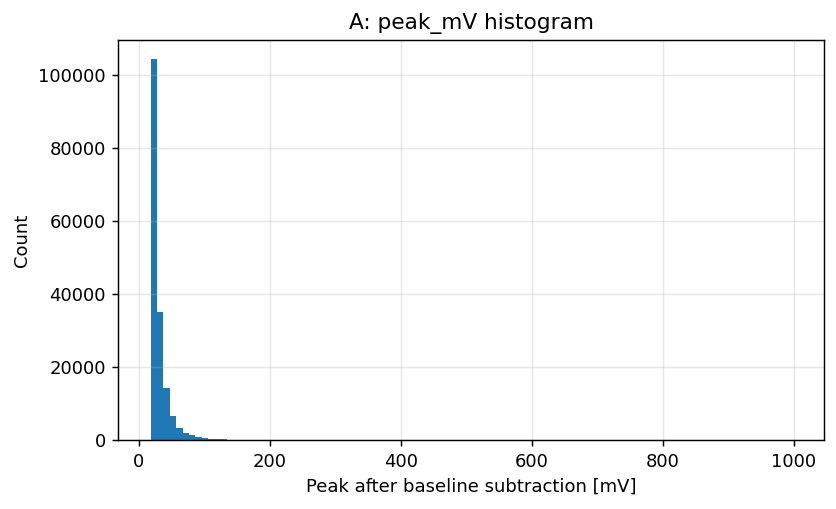

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_peak_hist_log.png


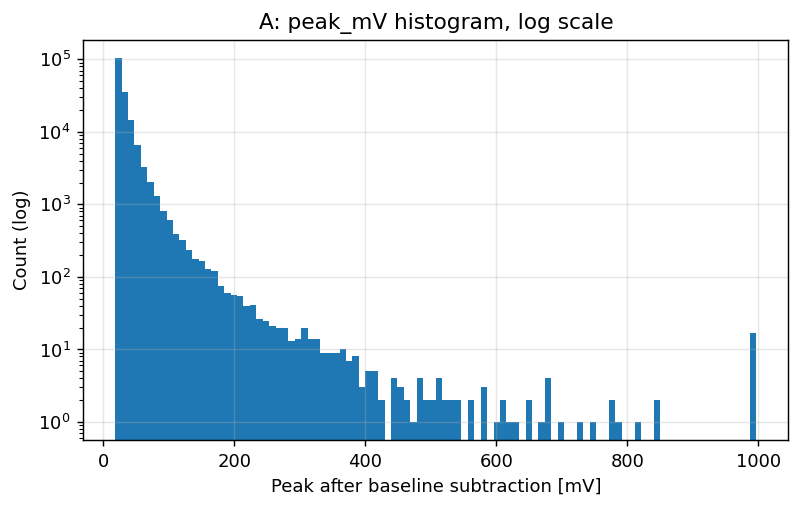

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_snr_peak_hist_log.png


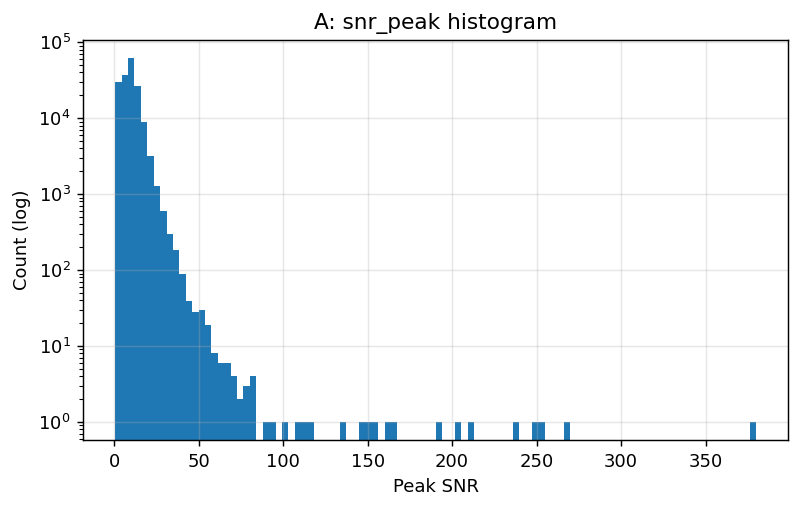

In [7]:
valid = features[features["valid_threshold_pulse"]].copy()

def save_current(fig, filename):
    path = OUTPUT_FIGURES / filename
    fig.savefig(path, bbox_inches="tight")
    print("Saved:", path)


def normalized_weights(values):
    return np.ones(len(values), dtype=float) / max(len(values), 1)


def linear_bins(values, n_bins=80, lower=None, upper=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if lower is None:
        lower = float(np.min(values))
    if upper is None:
        upper = float(np.max(values))
    if lower == upper:
        lower -= 0.5
        upper += 0.5
    return np.linspace(lower, upper, n_bins + 1)


def temporal_bins_8ns(values, margin_bins=1):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    lower = TEMPORAL_BIN_NS * np.floor(values.min() / TEMPORAL_BIN_NS) - margin_bins * TEMPORAL_BIN_NS
    upper = TEMPORAL_BIN_NS * np.ceil(values.max() / TEMPORAL_BIN_NS) + margin_bins * TEMPORAL_BIN_NS
    return np.arange(lower, upper + TEMPORAL_BIN_NS, TEMPORAL_BIN_NS)


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(valid["peak_mV"], bins=linear_bins(valid["peak_mV"], n_bins=100))
ax.set_xlabel("Peak after baseline subtraction [mV]")
ax.set_ylabel("Count")
ax.set_title(f"{PRIMARY_PANEL}: peak_mV histogram")
ax.grid(True, alpha=0.3)
save_current(fig, f"{PANEL_PREFIX}_threshold_peak_hist_linear.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(valid["peak_mV"], bins=linear_bins(valid["peak_mV"], n_bins=100))
ax.set_yscale("log")
ax.set_xlabel("Peak after baseline subtraction [mV]")
ax.set_ylabel("Count (log)")
ax.set_title(f"{PRIMARY_PANEL}: peak_mV histogram, log scale")
ax.grid(True, alpha=0.3)
save_current(fig, f"{PANEL_PREFIX}_threshold_peak_hist_log.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
snr_values = valid["snr_peak"].replace([np.inf, -np.inf], np.nan).dropna()
ax.hist(snr_values, bins=linear_bins(snr_values, n_bins=100))
ax.set_yscale("log")
ax.set_xlabel("Peak SNR")
ax.set_ylabel("Count (log)")
ax.set_title(f"{PRIMARY_PANEL}: snr_peak histogram")
ax.grid(True, alpha=0.3)
save_current(fig, f"{PANEL_PREFIX}_threshold_snr_peak_hist_log.png")
plt.show()


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_hist2d_integral_vs_peak_full.png


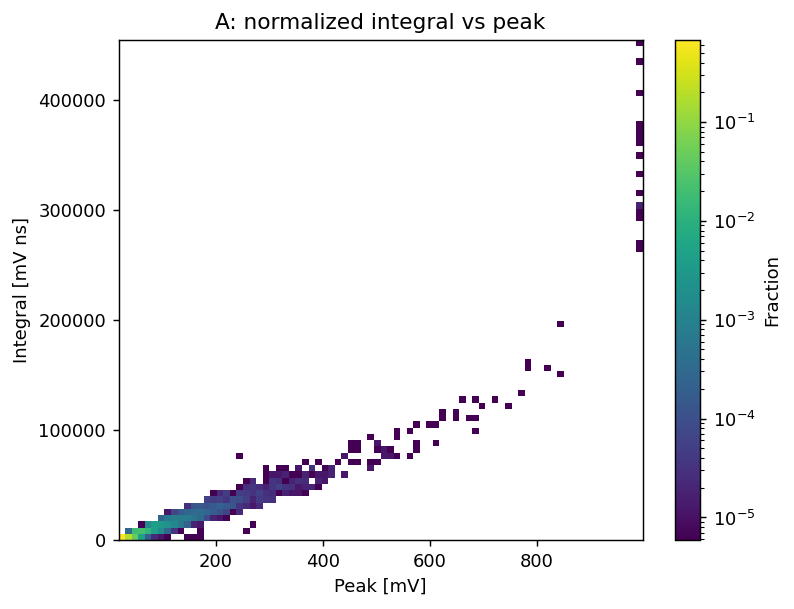

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_hist2d_integral_vs_width_full.png


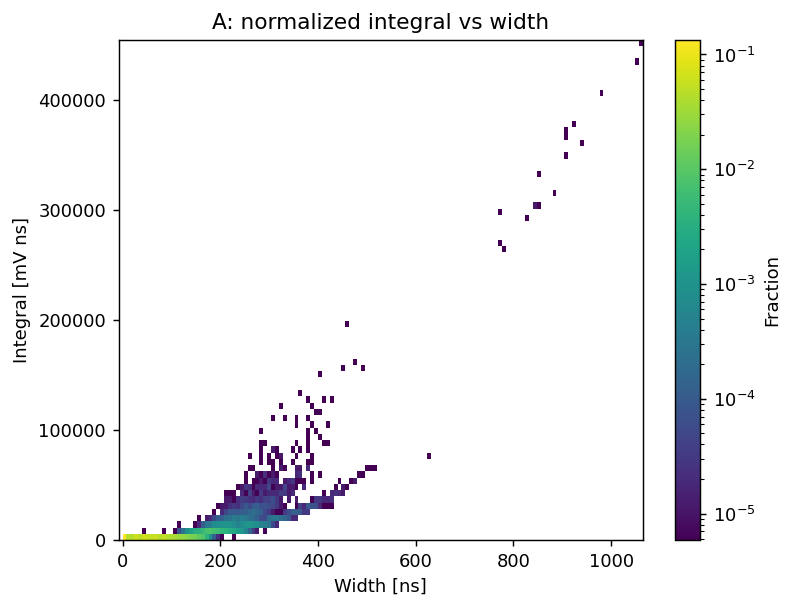

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_hist2d_peak_vs_snr_full.png


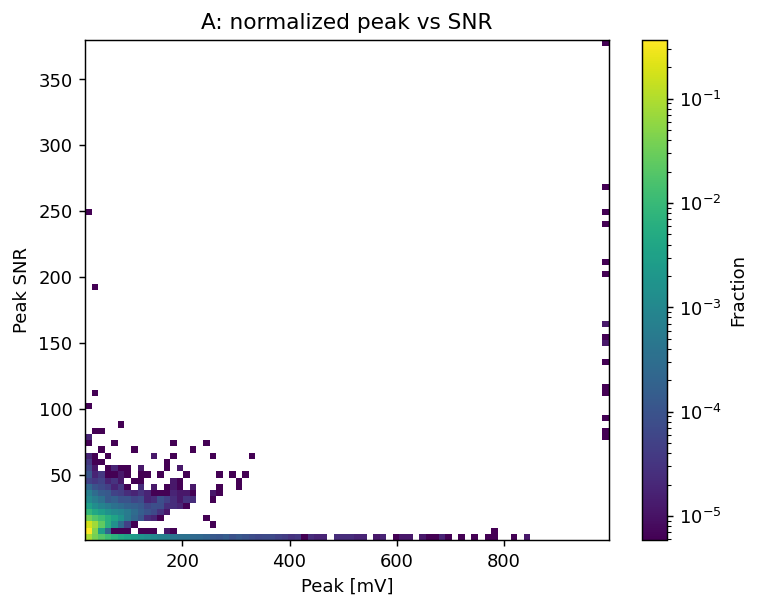

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_hist2d_integral_vs_peak_p5p95.png


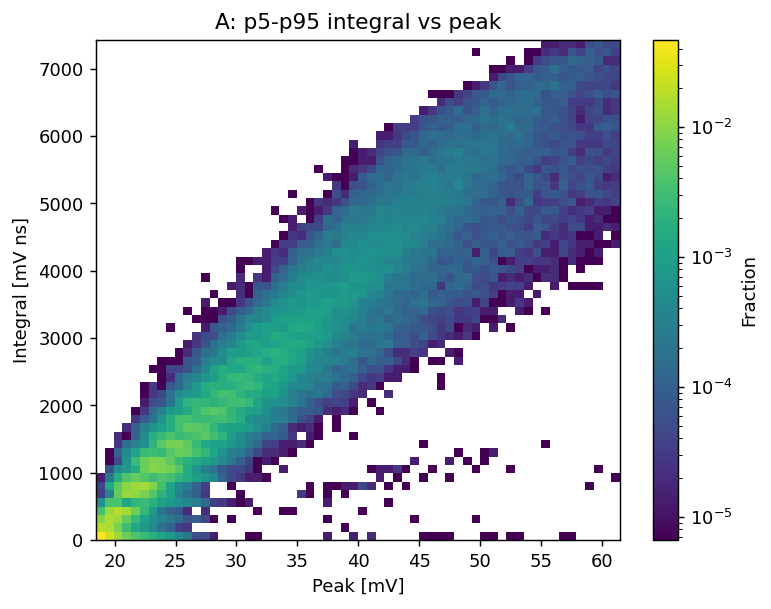

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_threshold_hist2d_integral_vs_width_p5p95.png


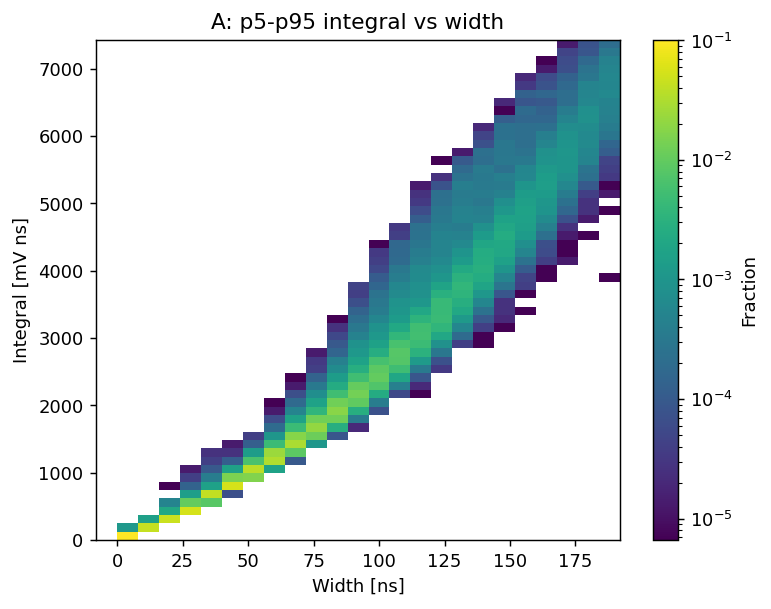

In [8]:
def plot_hist2d_normalized(df, x, y, x_bins, y_bins, xlabel, ylabel, title, filename, use_log=True):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    weights = np.ones(len(df), dtype=float) / max(len(df), 1)
    norm = LogNorm() if use_log else None
    hist = ax.hist2d(df[x], df[y], bins=[x_bins, y_bins], weights=weights, norm=norm)
    fig.colorbar(hist[3], ax=ax, label="Fraction")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    save_current(fig, filename)
    plt.show()


peak_bins = linear_bins(valid["peak_mV"], n_bins=80)
integral_bins = linear_bins(valid["integral_mVns"], n_bins=80)
width_bins = temporal_bins_8ns(valid["width_ns"])
snr_bins = linear_bins(valid["snr_peak"].replace([np.inf, -np.inf], np.nan).dropna(), n_bins=80)

plot_hist2d_normalized(
    valid,
    "peak_mV",
    "integral_mVns",
    peak_bins,
    integral_bins,
    "Peak [mV]",
    "Integral [mV ns]",
    f"{PRIMARY_PANEL}: normalized integral vs peak",
    f"{PANEL_PREFIX}_threshold_hist2d_integral_vs_peak_full.png",
)

plot_hist2d_normalized(
    valid,
    "width_ns",
    "integral_mVns",
    width_bins,
    integral_bins,
    "Width [ns]",
    "Integral [mV ns]",
    f"{PRIMARY_PANEL}: normalized integral vs width",
    f"{PANEL_PREFIX}_threshold_hist2d_integral_vs_width_full.png",
)

plot_hist2d_normalized(
    valid[np.isfinite(valid["snr_peak"])],
    "peak_mV",
    "snr_peak",
    peak_bins,
    snr_bins,
    "Peak [mV]",
    "Peak SNR",
    f"{PRIMARY_PANEL}: normalized peak vs SNR",
    f"{PANEL_PREFIX}_threshold_hist2d_peak_vs_snr_full.png",
)

p5 = valid[["peak_mV", "integral_mVns", "width_ns"]].quantile(0.05)
p95 = valid[["peak_mV", "integral_mVns", "width_ns"]].quantile(0.95)
trim = valid[
    valid["peak_mV"].between(p5["peak_mV"], p95["peak_mV"])
    & valid["integral_mVns"].between(p5["integral_mVns"], p95["integral_mVns"])
    & valid["width_ns"].between(p5["width_ns"], p95["width_ns"])
].copy()

plot_hist2d_normalized(
    trim,
    "peak_mV",
    "integral_mVns",
    linear_bins(trim["peak_mV"], n_bins=60),
    linear_bins(trim["integral_mVns"], n_bins=60),
    "Peak [mV]",
    "Integral [mV ns]",
    f"{PRIMARY_PANEL}: p5-p95 integral vs peak",
    f"{PANEL_PREFIX}_threshold_hist2d_integral_vs_peak_p5p95.png",
)

plot_hist2d_normalized(
    trim,
    "width_ns",
    "integral_mVns",
    temporal_bins_8ns(trim["width_ns"]),
    linear_bins(trim["integral_mVns"], n_bins=60),
    "Width [ns]",
    "Integral [mV ns]",
    f"{PRIMARY_PANEL}: p5-p95 integral vs width",
    f"{PANEL_PREFIX}_threshold_hist2d_integral_vs_width_p5p95.png",
)


## 6. Candidate minimum peak cuts


,min_peak_mV,n_pulses_retained,retained_fraction,rate_hz,median_peak_mV,median_integral_mVns,median_width_ns,median_baseline_rms_mV,median_snr_peak,peak_p5_mV,...,integral_p5_mVns,integral_p50_mVns,integral_p95_mVns,width_p5_ns,width_p50_ns,width_p95_ns,n_snr_ge_5,fraction_snr_ge_5,n_samples_above_threshold_ge_2,fraction_samples_above_threshold_ge_2
0,30.0,55236,0.324290,7.929274,39.284,3773.216,128.0,3.707983,10.669217,30.6220,...,2032.033050,3773.216,12963.720000,80.000000,128.0,232.0,38815,0.702712,55236,1.0
1,40.0,26449,0.155282,3.796824,51.850,5852.096,160.0,4.612369,11.186960,40.7480,...,3457.398555,5852.096,18617.297600,104.000000,160.0,264.0,15548,0.587848,26449,1.0
2,50.0,14536,0.085341,2.086681,65.514,8079.328,184.0,48.022897,1.885494,50.9960,...,4780.326000,8079.328,24838.103746,120.000000,184.0,288.0,6988,0.480737,14536,1.0
3,60.0,9031,0.053021,1.296424,79.239,10296.312,208.0,62.673950,1.448906,61.3355,...,6111.956000,10296.312,30675.680000,135.999908,208.0,312.0,3544,0.392426,9031,1.0
4,80.0,4402,0.025844,0.631919,105.957,14432.112,224.0,82.932196,1.415171,81.5570,...,8745.472400,14432.112,43250.244400,152.000000,224.0,352.0,1183,0.268741,4402,1.0
5,100.0,2543,0.014930,0.365054,133.773,18882.672,240.0,98.668513,1.467125,102.3031,...,11448.040800,18882.672,54130.326400,168.000000,240.0,376.0,498,0.195832,2543,1.0


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_min_peak_cut_diagnostic_curves.png


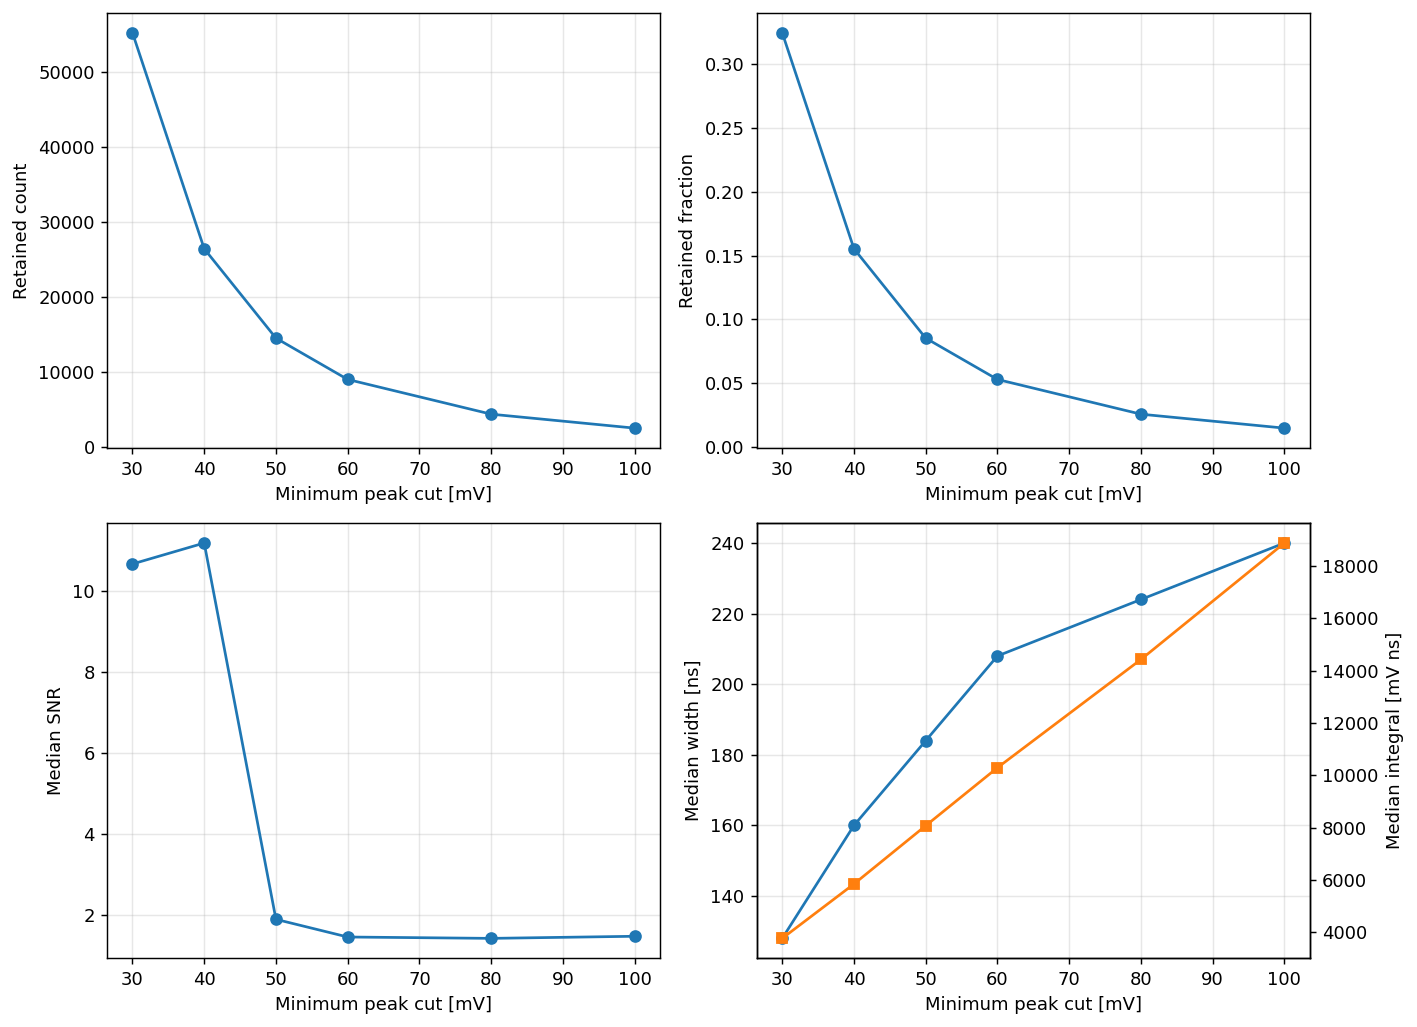

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_retained_fraction_vs_min_peak.png


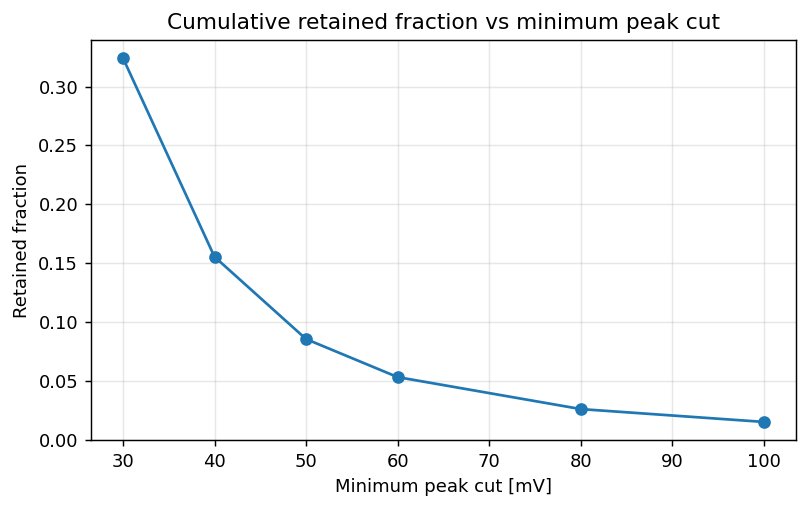

In [9]:
def quantile(series, q):
    return float(pd.to_numeric(series, errors="coerce").quantile(q))


cut_rows = []
for min_peak in MIN_PEAK_CANDIDATES_MV:
    subset = valid[valid["peak_mV"] >= min_peak].copy()
    retained = int(len(subset))
    fraction = retained / len(valid) if len(valid) else 0.0
    row = {
        "min_peak_mV": float(min_peak),
        "n_pulses_retained": retained,
        "retained_fraction": fraction,
        "rate_hz": retained / time_span_seconds if time_span_seconds > 0 else np.nan,
    }
    if retained > 0:
        row.update(
            {
                "median_peak_mV": float(subset["peak_mV"].median()),
                "median_integral_mVns": float(subset["integral_mVns"].median()),
                "median_width_ns": float(subset["width_ns"].median()),
                "median_baseline_rms_mV": float(subset["baseline_rms_mV"].median()),
                "median_snr_peak": float(subset["snr_peak"].replace([np.inf, -np.inf], np.nan).median()),
                "peak_p5_mV": quantile(subset["peak_mV"], 0.05),
                "peak_p50_mV": quantile(subset["peak_mV"], 0.50),
                "peak_p95_mV": quantile(subset["peak_mV"], 0.95),
                "integral_p5_mVns": quantile(subset["integral_mVns"], 0.05),
                "integral_p50_mVns": quantile(subset["integral_mVns"], 0.50),
                "integral_p95_mVns": quantile(subset["integral_mVns"], 0.95),
                "width_p5_ns": quantile(subset["width_ns"], 0.05),
                "width_p50_ns": quantile(subset["width_ns"], 0.50),
                "width_p95_ns": quantile(subset["width_ns"], 0.95),
                "n_snr_ge_5": int((subset["snr_peak"] >= 5).sum()),
                "fraction_snr_ge_5": float((subset["snr_peak"] >= 5).mean()),
                "n_samples_above_threshold_ge_2": int((subset["n_samples_above_threshold"] >= 2).sum()),
                "fraction_samples_above_threshold_ge_2": float((subset["n_samples_above_threshold"] >= 2).mean()),
            }
        )
    cut_rows.append(row)

cut_diagnostics = pd.DataFrame(cut_rows)
cut_diagnostics.to_csv(
    OUTPUT_TABLES / f"{PANEL_PREFIX}_min_peak_cut_diagnostics.csv",
    index=False,
)
display(cut_diagnostics)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
axes[0].plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["n_pulses_retained"], marker="o")
axes[0].set_ylabel("Retained count")
axes[1].plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["retained_fraction"], marker="o")
axes[1].set_ylabel("Retained fraction")
axes[2].plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["median_snr_peak"], marker="o")
axes[2].set_ylabel("Median SNR")
axes[3].plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["median_width_ns"], marker="o", label="width [ns]")
ax2 = axes[3].twinx()
ax2.plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["median_integral_mVns"], marker="s", color="tab:orange", label="integral")
axes[3].set_ylabel("Median width [ns]")
ax2.set_ylabel("Median integral [mV ns]")
for ax in axes:
    ax.set_xlabel("Minimum peak cut [mV]")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_current(fig, f"{PANEL_PREFIX}_min_peak_cut_diagnostic_curves.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cut_diagnostics["min_peak_mV"], cut_diagnostics["retained_fraction"], marker="o")
ax.set_xlabel("Minimum peak cut [mV]")
ax.set_ylabel("Retained fraction")
ax.set_title("Cumulative retained fraction vs minimum peak cut")
ax.grid(True, alpha=0.3)
save_current(fig, f"{PANEL_PREFIX}_retained_fraction_vs_min_peak.png")
plt.show()


## 7. Data-driven suggestion

`18 mV` defines the pulse start/end after baseline subtraction. A higher `MIN_PEAK_MV` is needed because pulses close to threshold can have poor SNR and are not well modeled by the current detector simulation.

The final cut should be selected from the peak histogram and stability table. `50 mV` is a reasonable preliminary candidate only if the histogram shows that it removes the low-amplitude pedestal while preserving enough statistics. `100 mV` may be too restrictive unless the distribution clearly supports it.


,panel,threshold_mV,suggested_min_peak_mV,method,final_cut_status
0,A,18.0,119.3625,diagnostic smoothed histogram local minimum be...,"diagnostic suggestion only, not final"


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_peak_cut_suggestion.png


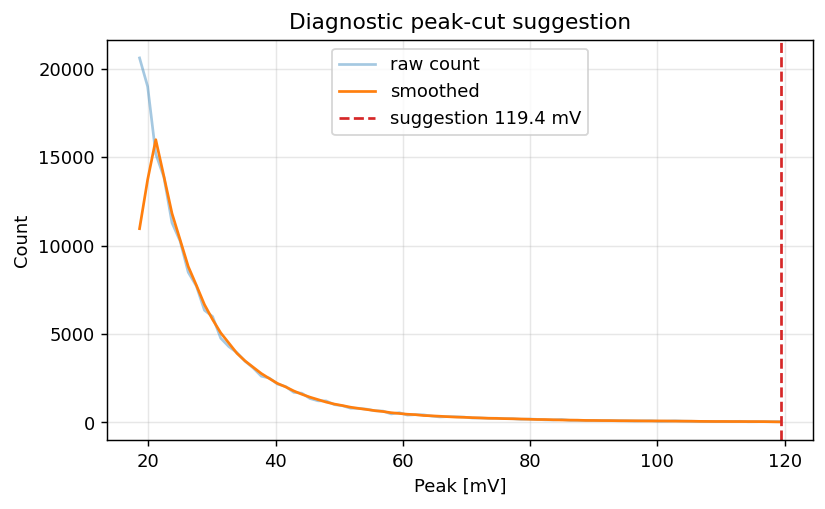

In [10]:
def suggest_min_peak_from_histogram(peaks, low=18.0, high=120.0, n_bins=80, smooth_window=5):
    values = pd.to_numeric(peaks, errors="coerce").to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    values = values[(values >= low) & (values <= high)]
    if len(values) < 20:
        return np.nan, pd.DataFrame()
    counts, edges = np.histogram(values, bins=n_bins, range=(low, high))
    centers = 0.5 * (edges[:-1] + edges[1:])
    kernel = np.ones(smooth_window) / smooth_window
    smooth = np.convolve(counts, kernel, mode="same")
    peak_idx = int(np.argmax(smooth))
    if peak_idx >= len(smooth) - 3:
        suggestion = np.nan
    else:
        search = smooth[peak_idx + 1 :]
        local_min_idx = int(np.argmin(search)) + peak_idx + 1
        suggestion = float(centers[local_min_idx])
    table = pd.DataFrame({"peak_mV_bin_center": centers, "count": counts, "smoothed_count": smooth})
    return suggestion, table


suggested_min_peak_mV, smoothed_hist = suggest_min_peak_from_histogram(valid["peak_mV"])
suggestion = pd.DataFrame(
    [
        {
            "panel": PRIMARY_PANEL,
            "threshold_mV": THRESHOLD_MV,
            "suggested_min_peak_mV": suggested_min_peak_mV,
            "method": "diagnostic smoothed histogram local minimum between 18 and 120 mV",
            "final_cut_status": "diagnostic suggestion only, not final",
        }
    ]
)
suggestion.to_csv(
    OUTPUT_TABLES / f"{PANEL_PREFIX}_peak_cut_suggestion.csv",
    index=False,
)
smoothed_hist.to_csv(
    OUTPUT_TABLES / f"{PANEL_PREFIX}_peak_histogram_smoothed_for_cut_suggestion.csv",
    index=False,
)
display(suggestion)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(smoothed_hist["peak_mV_bin_center"], smoothed_hist["count"], alpha=0.4, label="raw count")
ax.plot(smoothed_hist["peak_mV_bin_center"], smoothed_hist["smoothed_count"], label="smoothed")
if np.isfinite(suggested_min_peak_mV):
    ax.axvline(suggested_min_peak_mV, color="tab:red", linestyle="--", label=f"suggestion {suggested_min_peak_mV:.1f} mV")
ax.set_xlabel("Peak [mV]")
ax.set_ylabel("Count")
ax.set_title("Diagnostic peak-cut suggestion")
ax.grid(True, alpha=0.3)
ax.legend()
save_current(fig, f"{PANEL_PREFIX}_peak_cut_suggestion.png")
plt.show()


## 8. Representative waveform overlays


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_waveforms_peak_18_30mV.png


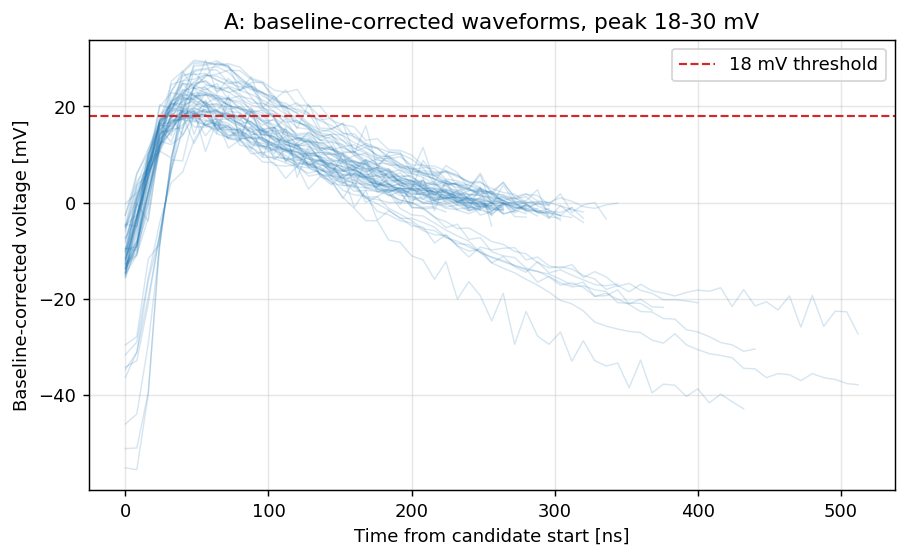

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_waveforms_peak_30_50mV.png


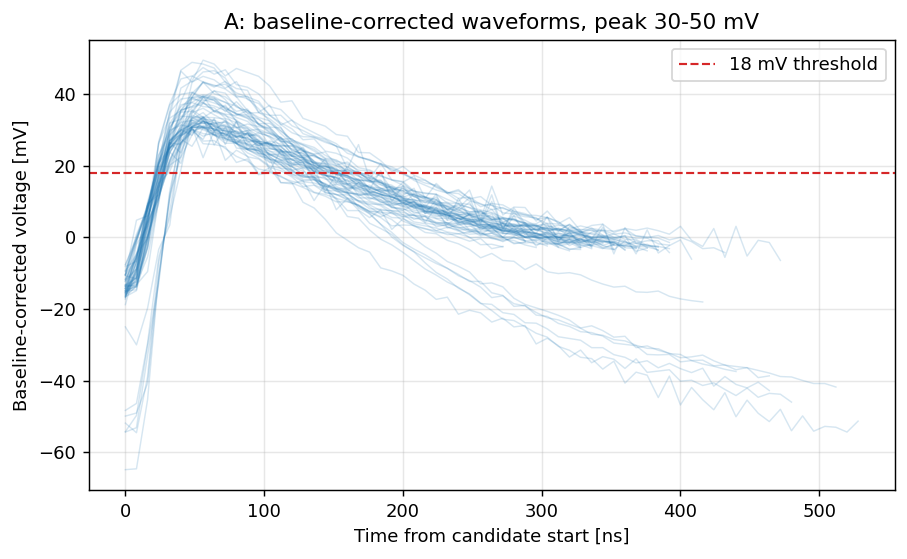

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_waveforms_peak_gt50mV.png


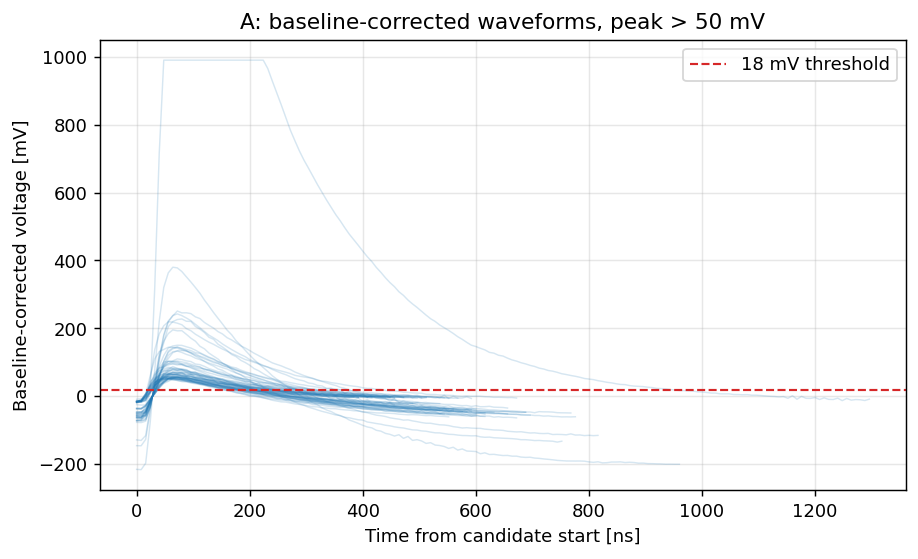

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures\latest_h5_panel_A_waveforms_peak_gt100mV.png


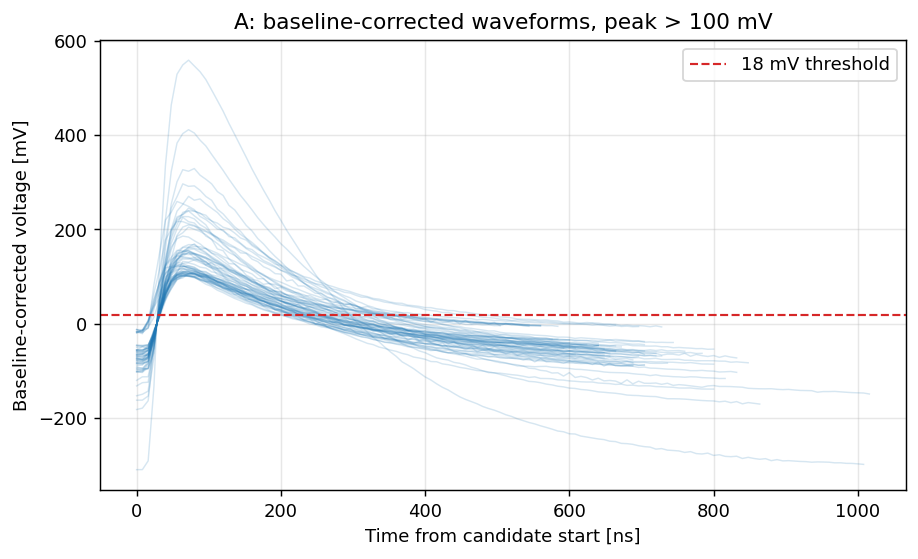

In [11]:
def plot_waveform_group(features, samples, mask, filename, title, n_waveforms=60):
    subset = features[mask & features["valid_threshold_pulse"]].copy()
    if subset.empty:
        print("No waveforms for", title)
        return
    subset = subset.sample(n=min(n_waveforms, len(subset)), random_state=RANDOM_SEED)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for _, row in subset.iterrows():
        start = int(row["row_start"])
        end = int(row["row_end"])
        candidate = samples.iloc[start : end + 1]
        t = candidate["time_ns"].to_numpy(dtype=float)
        t = t - t[0]
        v = candidate["voltage_mV"].to_numpy(dtype=float) - float(row["baseline_mV"])
        ax.plot(t, v, color="tab:blue", alpha=0.18, linewidth=0.8)
    ax.axhline(THRESHOLD_MV, color="tab:red", linestyle="--", linewidth=1.2, label=f"{THRESHOLD_MV:g} mV threshold")
    ax.set_xlabel("Time from candidate start [ns]")
    ax.set_ylabel("Baseline-corrected voltage [mV]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_current(fig, filename)
    plt.show()


plot_waveform_group(
    features,
    samples,
    features["peak_mV"].between(18, 30, inclusive="left"),
    f"{PANEL_PREFIX}_waveforms_peak_18_30mV.png",
    f"{PRIMARY_PANEL}: baseline-corrected waveforms, peak 18-30 mV",
)
plot_waveform_group(
    features,
    samples,
    features["peak_mV"].between(30, 50, inclusive="left"),
    f"{PANEL_PREFIX}_waveforms_peak_30_50mV.png",
    f"{PRIMARY_PANEL}: baseline-corrected waveforms, peak 30-50 mV",
)
plot_waveform_group(
    features,
    samples,
    features["peak_mV"] >= 50,
    f"{PANEL_PREFIX}_waveforms_peak_gt50mV.png",
    f"{PRIMARY_PANEL}: baseline-corrected waveforms, peak > 50 mV",
)
plot_waveform_group(
    features,
    samples,
    features["peak_mV"] >= 100,
    f"{PANEL_PREFIX}_waveforms_peak_gt100mV.png",
    f"{PRIMARY_PANEL}: baseline-corrected waveforms, peak > 100 mV",
)


## 9. Output summary


In [12]:
summary_lines = [
    f"# Latest HDF5 Panel {PRIMARY_PANEL} Thresholded Pulse Selection Summary",
    "",
    f"- File used: `{DATA_H5}`",
    f"- Total samples loaded: {total_samples}",
    f"- Time span seconds: {time_span_seconds:.6f}",
    f"- Estimated sampling interval ns: {estimated_dt_ns:.6f}",
    f"- Candidate windows from gap segmentation: {len(candidate_windows)}",
    f"- Candidate rate Hz: {candidate_rate_hz:.6f}",
    f"- Valid threshold pulses: {int(features['valid_threshold_pulse'].sum())}",
    f"- Threshold definition: local baseline-subtracted peak must reach {THRESHOLD_MV:g} mV; pulse start/end are the contiguous region around the main peak above {THRESHOLD_MV:g} mV.",
    f"- Baseline method: median of early pre-peak samples when available; otherwise low-percentile median. Baseline RMS uses MAD scaled by 1.4826.",
    "- Integral convention: trapezoidal integration over the thresholded interval using baseline-corrected voltage.",
    "- Temporal binning: 8 ns, fixed by Red Pitaya FPGA resolution.",
    "",
    "## Recommended next step",
    "",
    "Inspect the peak histogram, SNR histogram, waveform overlays, and the minimum-peak cut stability table before selecting a final `MIN_PEAK_MV` for the final real-vs-sim matching notebook.",
    "",
    "Low-amplitude pulses should not be discarded silently. They should be treated as a separate diagnostic population because they may include low-SNR candidates, noise, or pulses not modeled by the current detector simulation.",
]
summary_path = OUTPUT_TABLES / f"{PANEL_PREFIX}_thresholded_pulse_selection_summary.md"
summary_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
print(summary_path.read_text(encoding="utf-8"))


# Latest HDF5 Panel A Thresholded Pulse Selection Summary

- File used: `C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03A_040526_1h50m_AMP5_C5_thr0_82.h5`
- Total samples loaded: 14682944
- Time span seconds: 6966.085125
- Estimated sampling interval ns: 8.000000
- Candidate windows from gap segmentation: 426568
- Candidate rate Hz: 61.234968
- Valid threshold pulses: 170329
- Threshold definition: local baseline-subtracted peak must reach 18 mV; pulse start/end are the contiguous region around the main peak above 18 mV.
- Baseline method: median of early pre-peak samples when available; otherwise low-percentile median. Baseline RMS uses MAD scaled by 1.4826.
- Integral convention: trapezoidal integration over the thresholded interval using baseline-corrected voltage.
- Temporal binning: 8 ns, fixed by Red Pitaya FPGA resolution.

## Recommended next step

Inspect the peak histogram, SNR histogram, waveform overlays, and the minimum-p